<a href="https://colab.research.google.com/github/a01723855-sketch/Andres-Marroquin/blob/main/A5_Visualizaci%C3%B3n_con_Histogramas_%26_Boxplots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Subir el archivo CSV
uploaded = files.upload()

# Leer el archivo
nombre_archivo = next(iter(uploaded))
df = pd.read_csv(nombre_archivo)

# Mostrar los primeros registros
display(df.head())

# Revisar nombres de columnas y tipos de datos
print("Columnas:", df.columns.tolist())
print("\nDimensiones del dataset:", df.shape)
print("\nInformación del dataset:")
df.info()


Saving antropometria-dataset-1-1.csv to antropometria-dataset-1-1.csv


,folio,intp,entidad,desc_ent,sexo,edad,meses,peso,ropa,talla,...,hpresion,tbrazo,htension,PrimaryLast,code_upm,est_dis,est_urb,est_marg,pondef,est_var
0,210295,2,21,PUEBLA,2,38,8,73.70,2,146.4,...,16:30,2,16:35,1,R2101,5,3,1,3470.002176,215
1,101655,3,10,DURANGO,2,11,11,35.65,2,145.1,...,15:25,3,15:25,1,M1041,1,1,1,417.946672,101
2,10287,6,1,AGUASCALIENTES,2,18,8,54.80,1,162.0,...,9:40,1,9:40,1,M0108,5,3,1,472.980811,15
3,91526,4,9,DISTRITO FEDERAL,1,10,8,33.40,2,146.5,...,7:40,3,7:45,1,M0931,4,3,2,1832.581391,94
4,210939,3,21,PUEBLA,2,19,3,97.95,2,161.0,...,6:00,2,6:00,1,M2123,5,3,1,7622.066564,215


Columnas: ['folio', 'intp', 'entidad', 'desc_ent', 'sexo', 'edad', 'meses', 'peso', 'ropa', 'talla', 'emb', 'temb', 'cintura', 'cadera', 'sistol', 'diastol', 'hpresion', 'tbrazo', 'htension', 'PrimaryLast', 'code_upm', 'est_dis', 'est_urb', 'est_marg', 'pondef', 'est_var']

Dimensiones del dataset: (18640, 26)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18640 entries, 0 to 18639
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   folio        18640 non-null  int64  
 1   intp         18640 non-null  int64  
 2   entidad      18640 non-null  int64  
 3   desc_ent     18640 non-null  object 
 4   sexo         18640 non-null  int64  
 5   edad         18640 non-null  int64  
 6   meses        18640 non-null  int64  
 7   peso         18640 non-null  float64
 8   ropa         18640 non-null  int64  
 9   talla        18640 non-null  float64
 10  emb          18640 non-null  object 
 11  te

In [2]:

# Variables que analizaremos
variables = [
    'peso', 'cintura', 'cadera',
    'talla', 'sistol', 'diastol'
]

# Verificar que existan las columnas
print(df[variables].describe())

# Revisar valores faltantes
print("\nValores faltantes:")
print(df[variables + ['sexo']].isnull().sum())

# Revisar las categorías de sexo
print("\nFrecuencia por sexo:")
print(df['sexo'].value_counts().sort_index())


               peso       cintura        cadera         talla        sistol  \
count  18640.000000  18032.000000  18032.000000  18640.000000  18640.000000   
mean      64.638707     87.778529     97.733534    156.558291    118.473739   
std       17.660325     16.950062     14.266419     10.620573     17.261616   
min       18.000000     11.900000     14.100000    104.450000     63.250000   
25%       52.700000     76.000000     89.750000    149.400000    108.250000   
50%       63.700000     87.250000     97.150000    156.400000    117.000000   
75%       75.400000     98.000000    105.000000    163.962500    126.250000   
max      170.600000    222.220000    222.220000    194.500000    240.000000   

            diastol  
count  18640.000000  
mean      75.517570  
std       11.374321  
min       39.000000  
25%       69.000000  
50%       75.000000  
75%       81.000000  
max      150.000000  

Valores faltantes:
peso         0
cintura    608
cadera     608
talla        0
sistol    

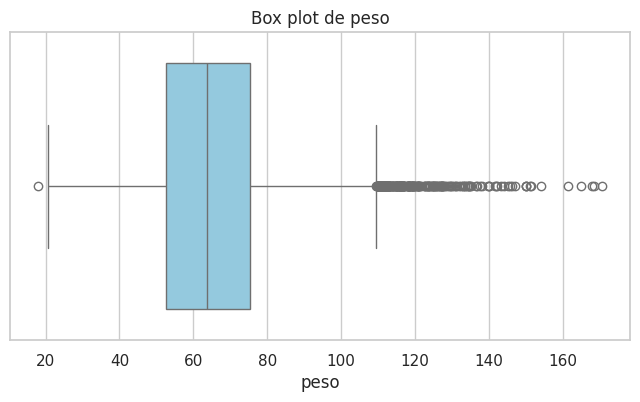

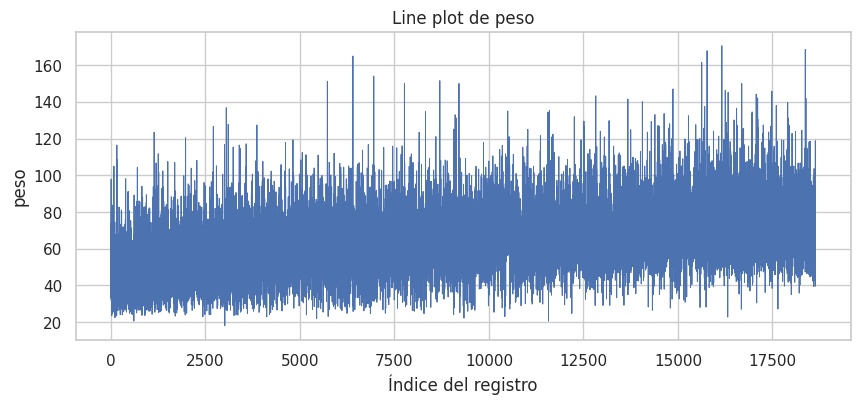

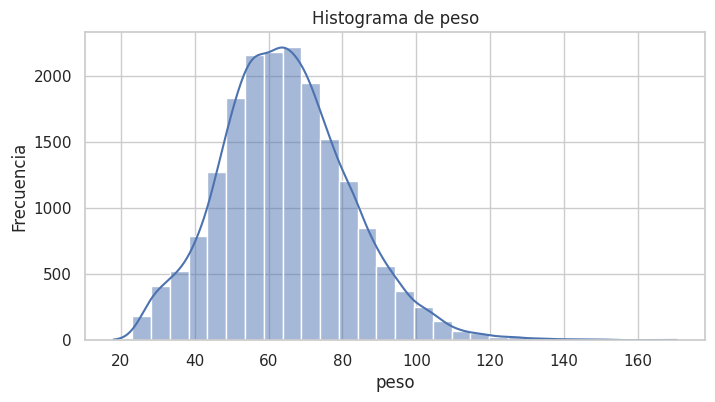

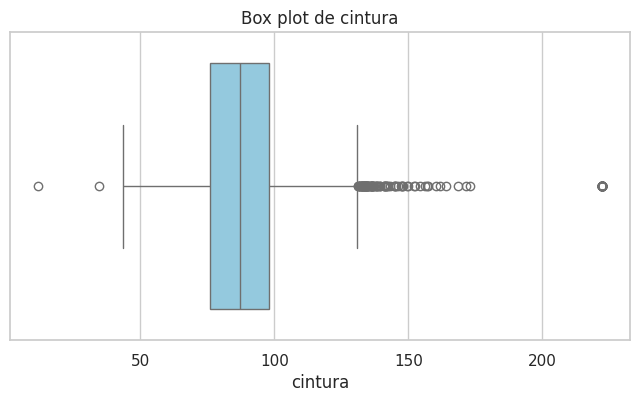

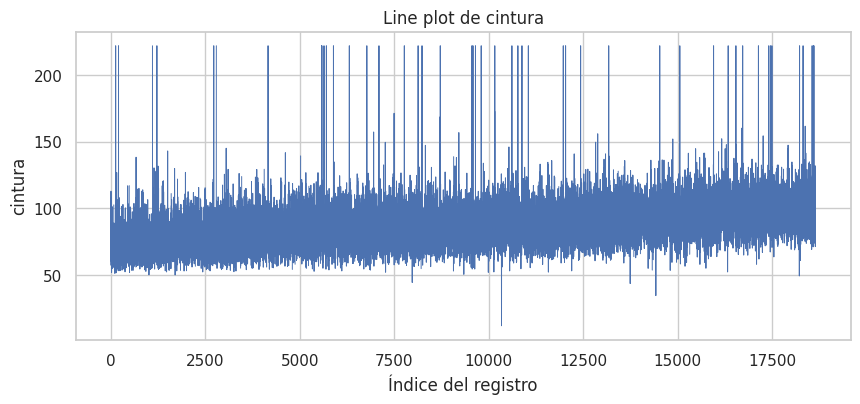

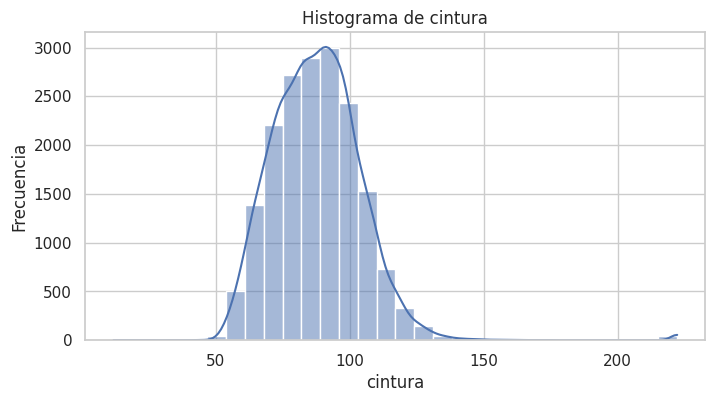

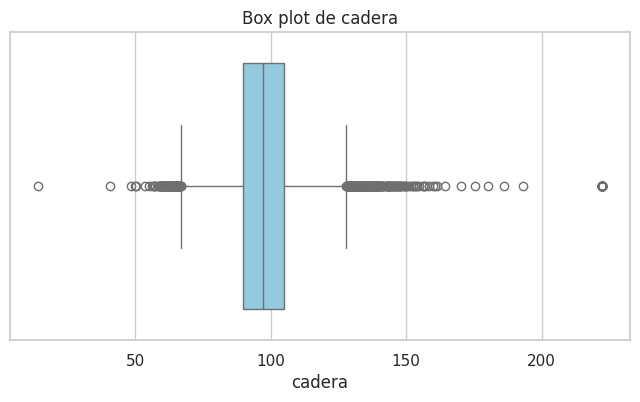

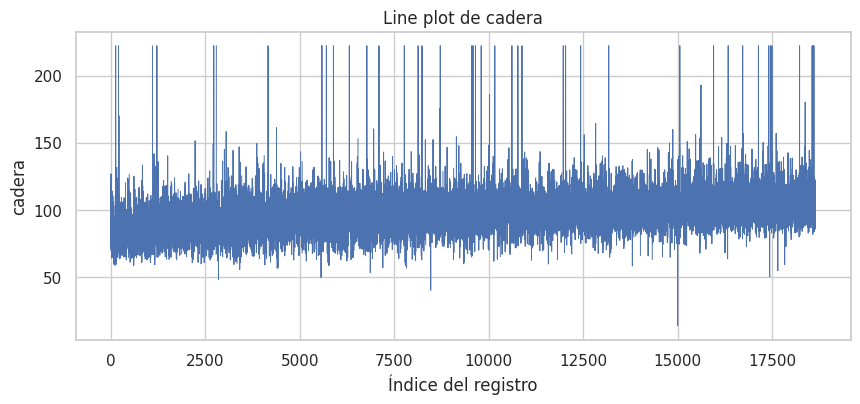

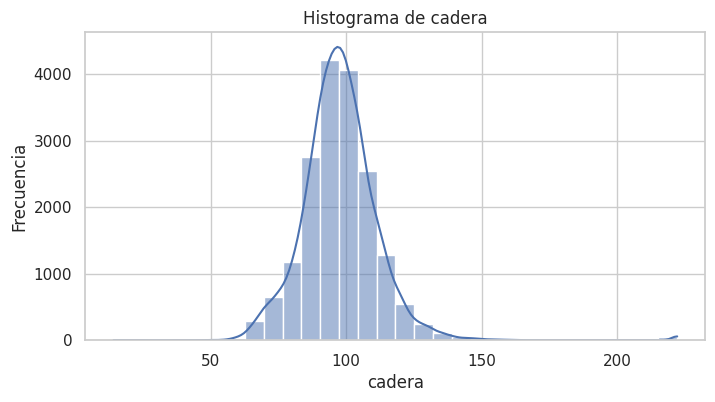

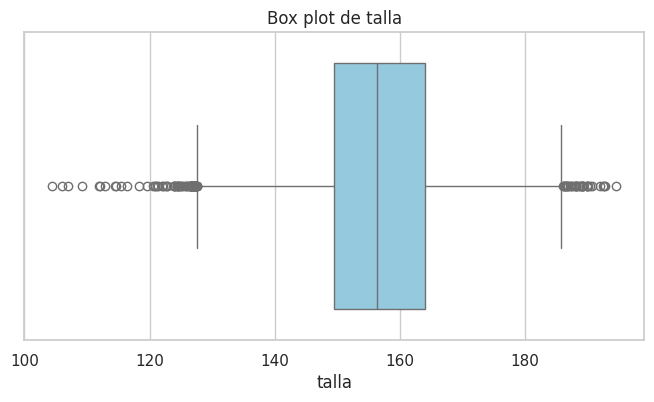

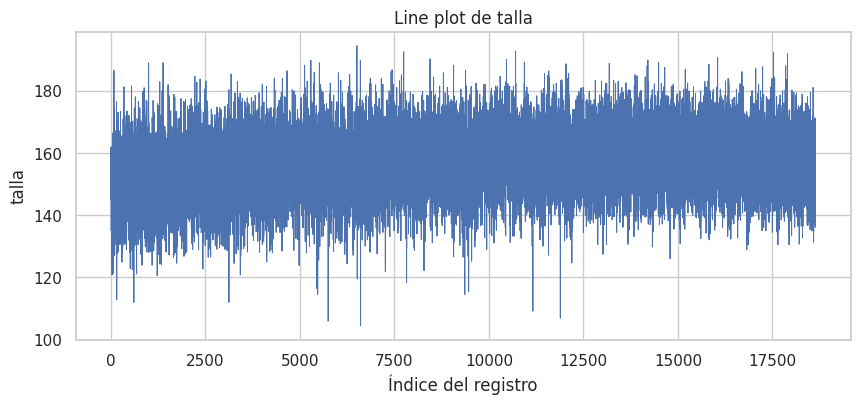

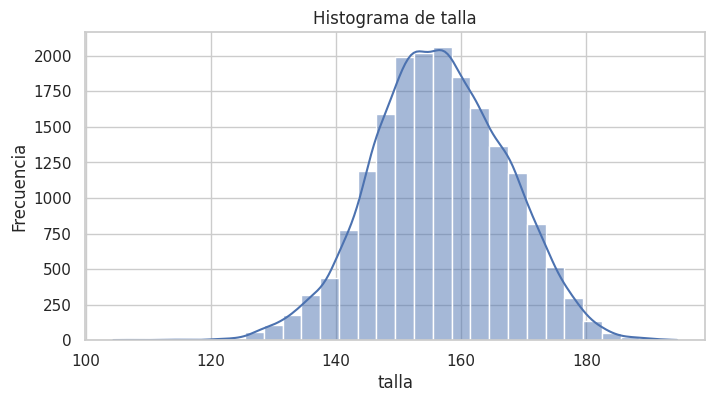

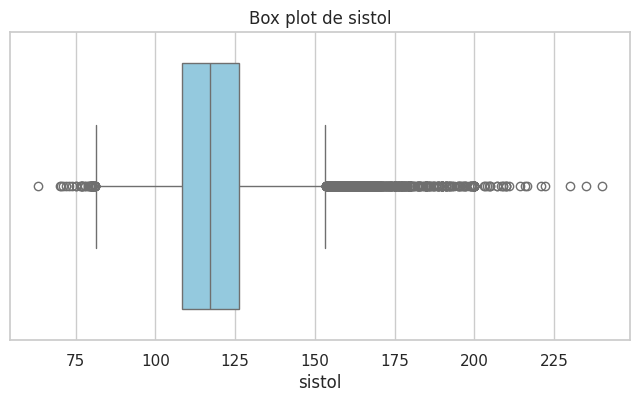

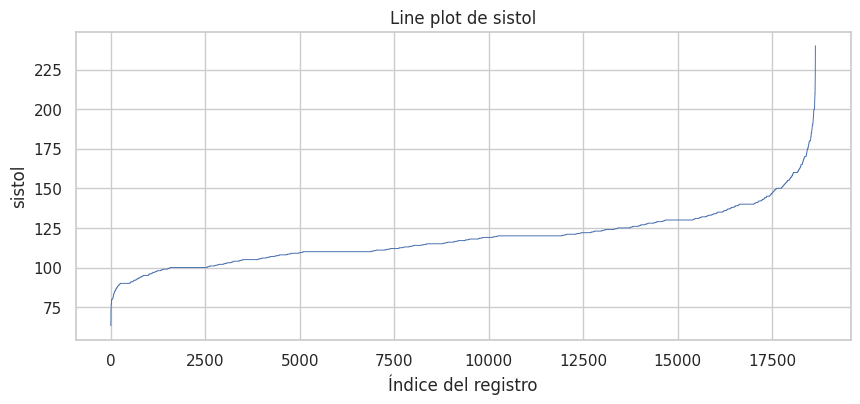

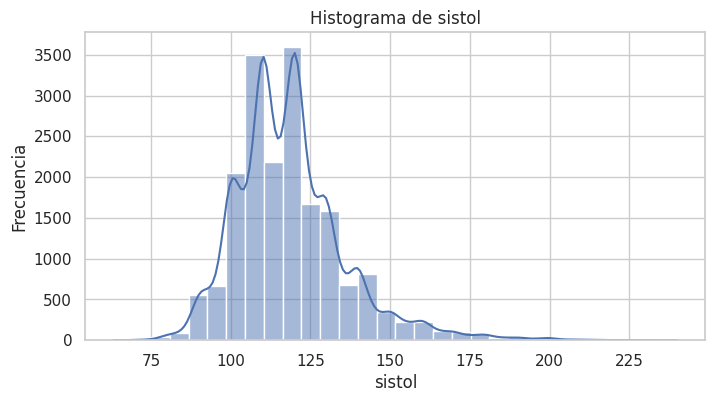

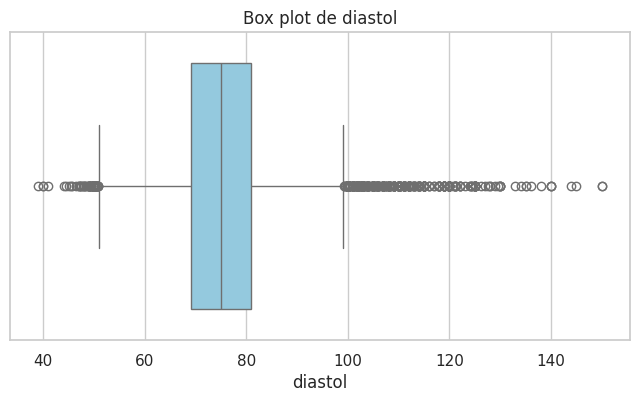

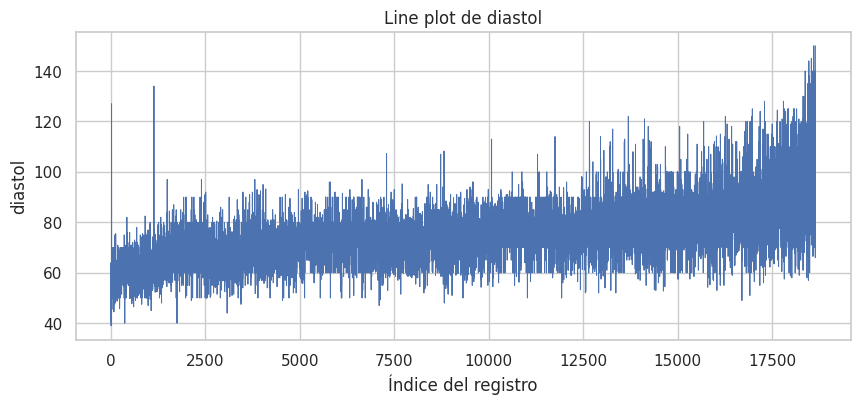

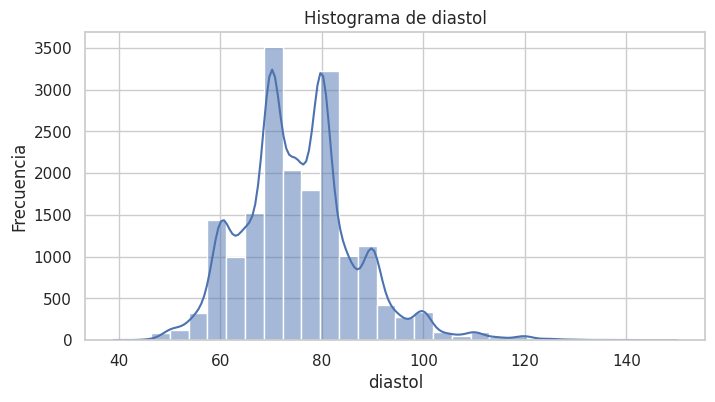

In [3]:

sns.set_theme(style="whitegrid")

for variable in variables:

    # Box plot
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[variable], color='skyblue')
    plt.title(f'Box plot de {variable}')
    plt.xlabel(variable)
    plt.show()

    # Line plot: valores según el orden de los registros
    plt.figure(figsize=(10, 4))
    plt.plot(df.index, df[variable], linewidth=0.7)
    plt.title(f'Line plot de {variable}')
    plt.xlabel('Índice del registro')
    plt.ylabel(variable)
    plt.show()

    # Histograma
    plt.figure(figsize=(8, 4))
    sns.histplot(df[variable].dropna(), bins=30, kde=True)
    plt.title(f'Histograma de {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')
    plt.show()



Análisis para sexo = 1
Número de registros: 8154


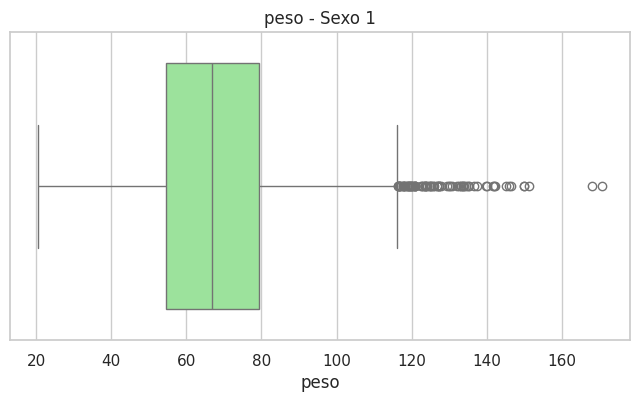

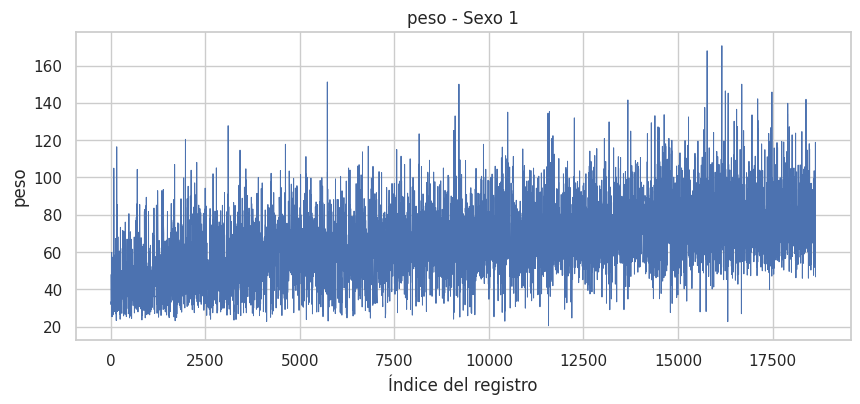

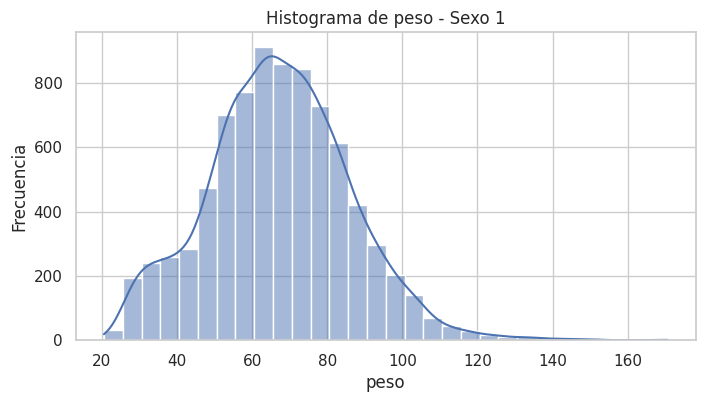

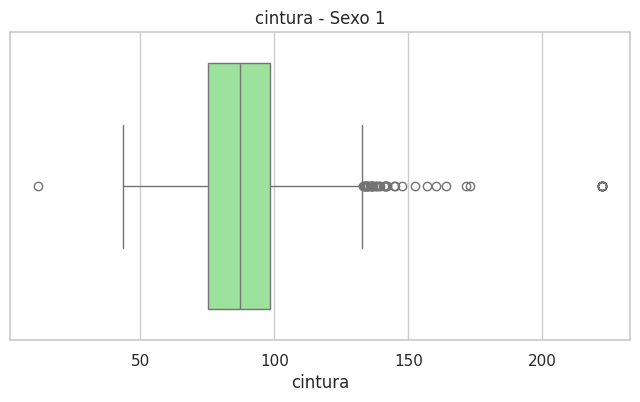

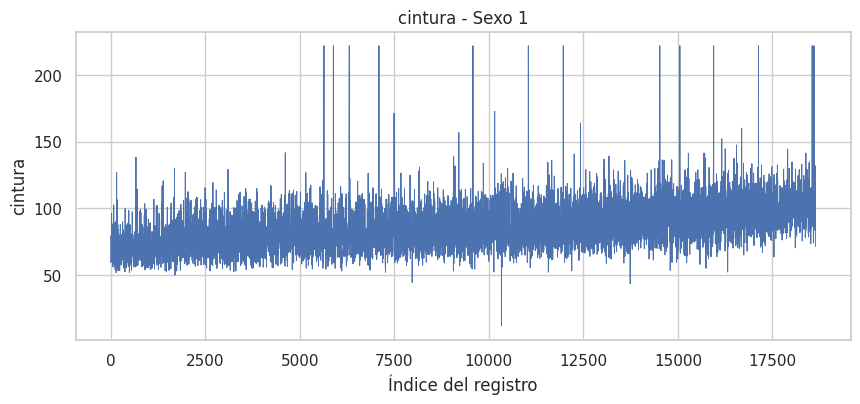

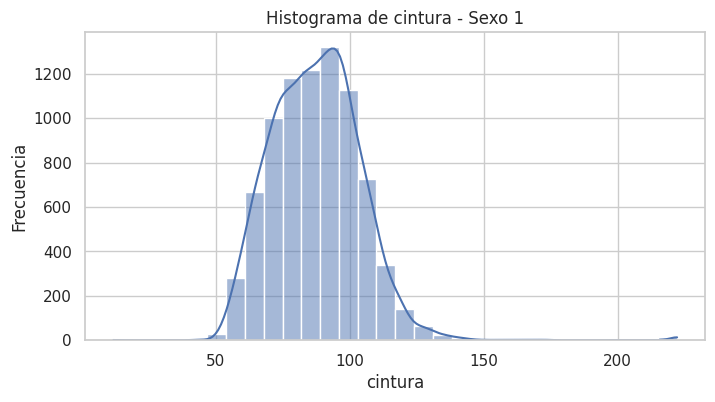

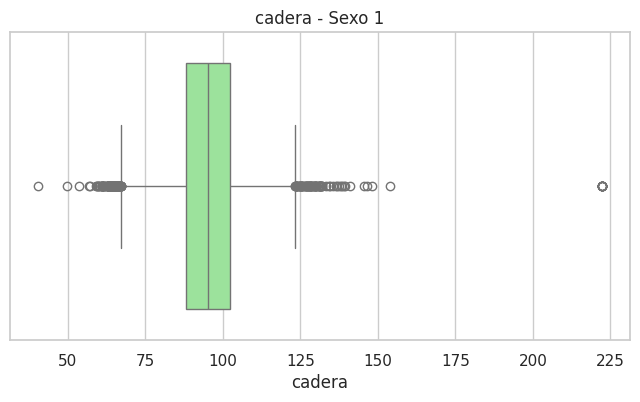

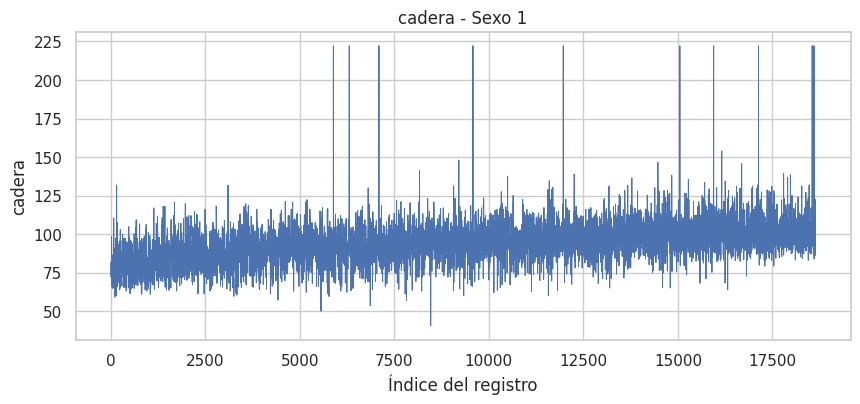

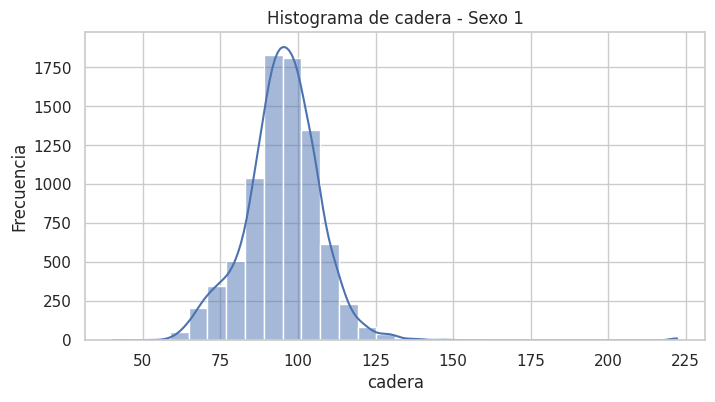

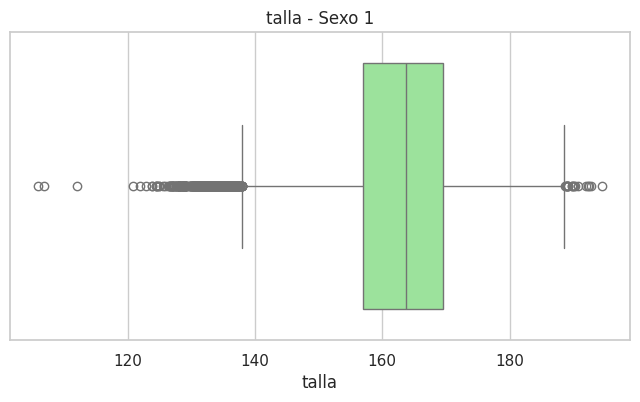

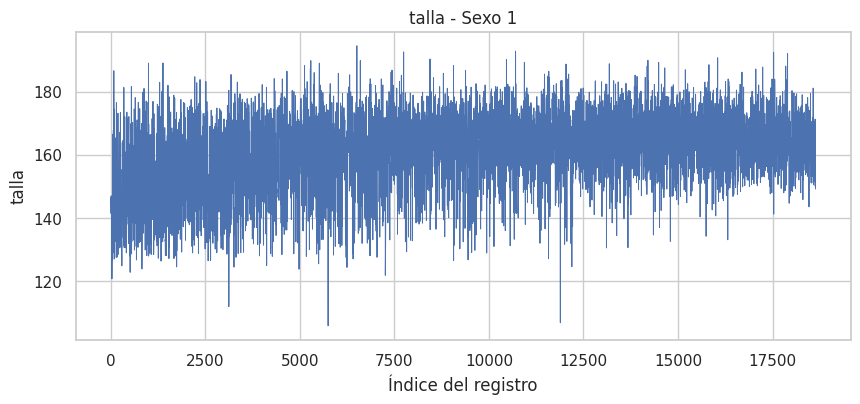

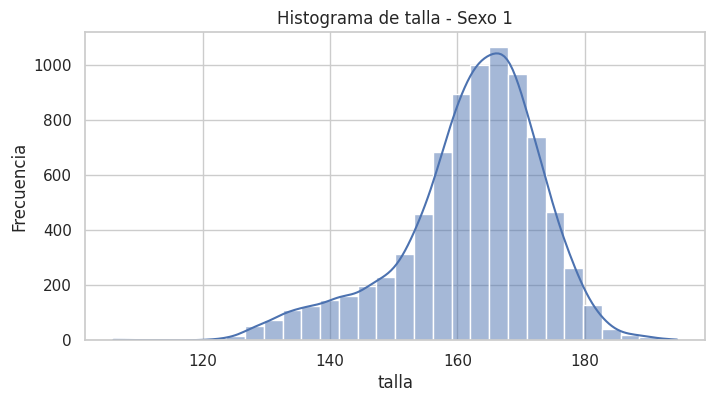

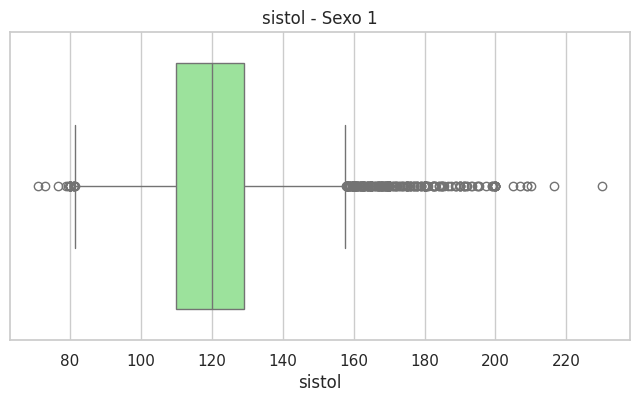

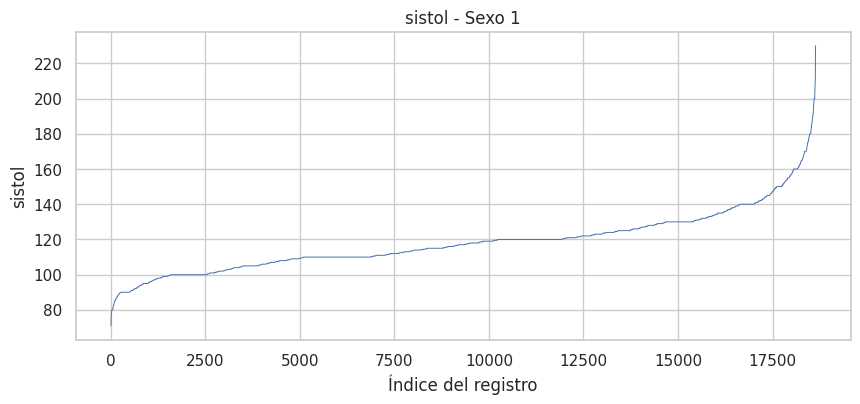

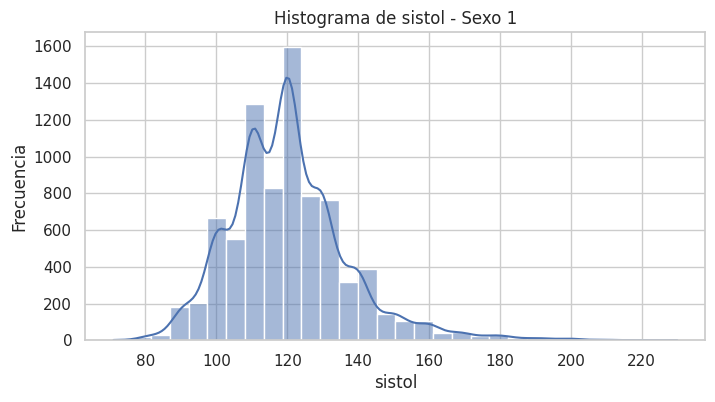

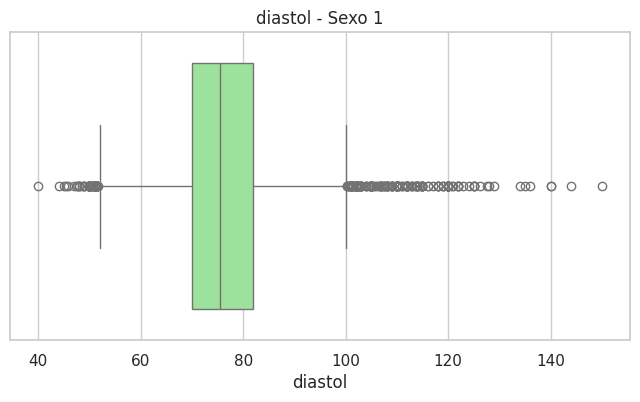

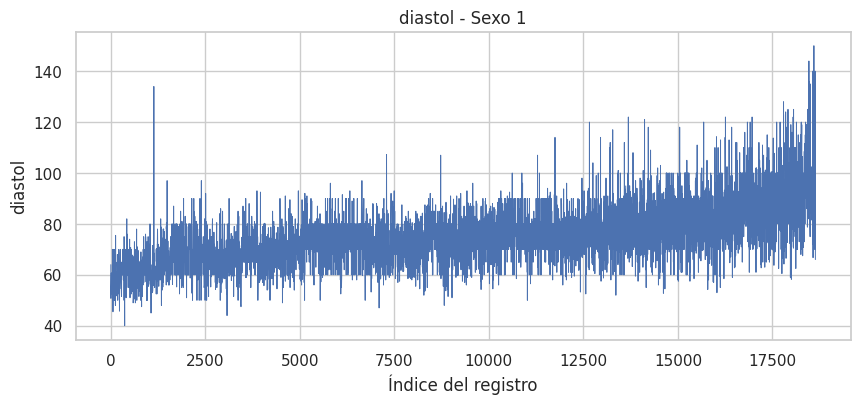

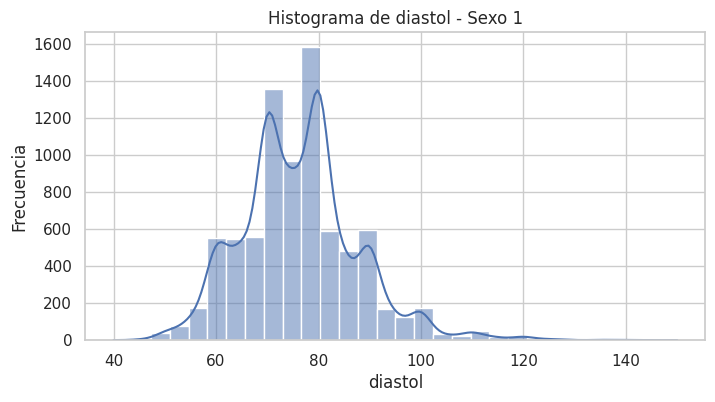


Análisis para sexo = 2
Número de registros: 10486


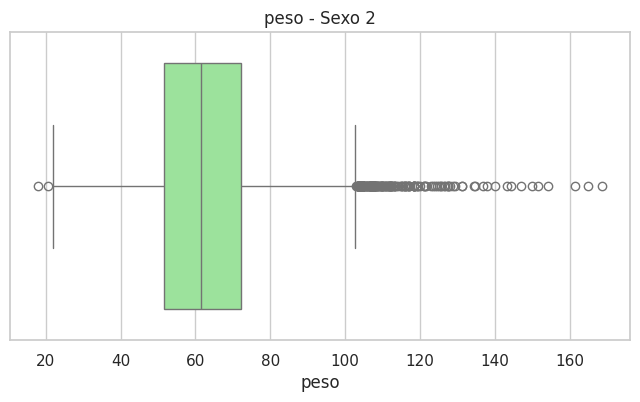

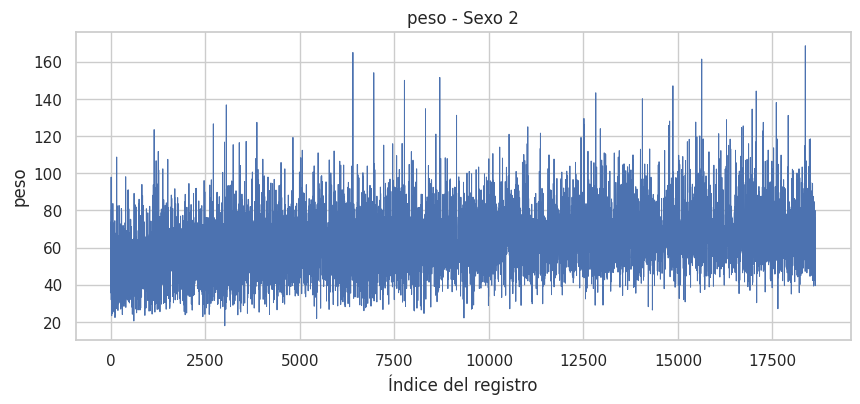

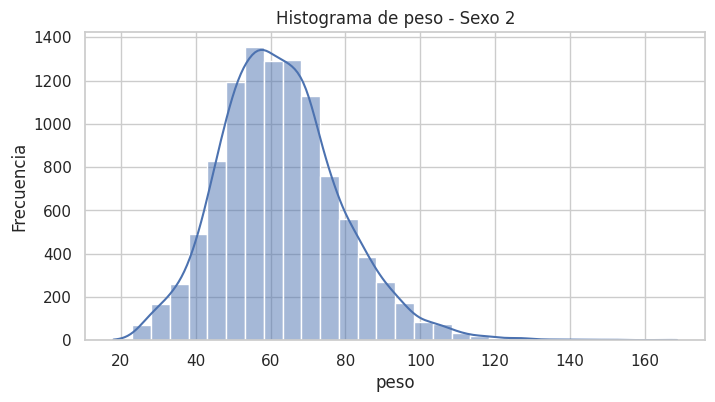

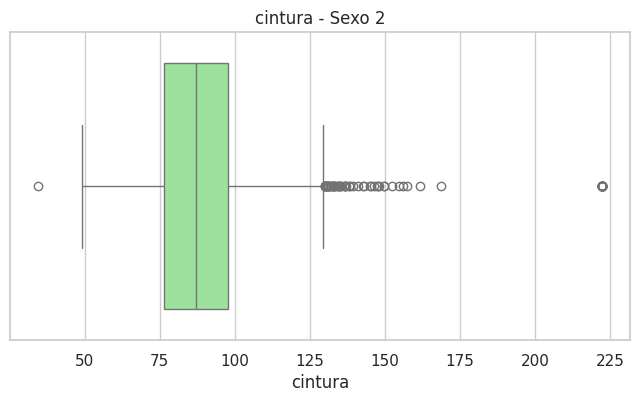

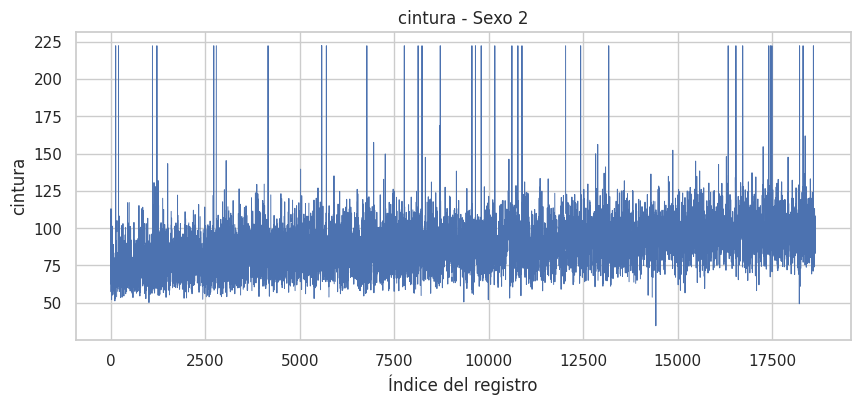

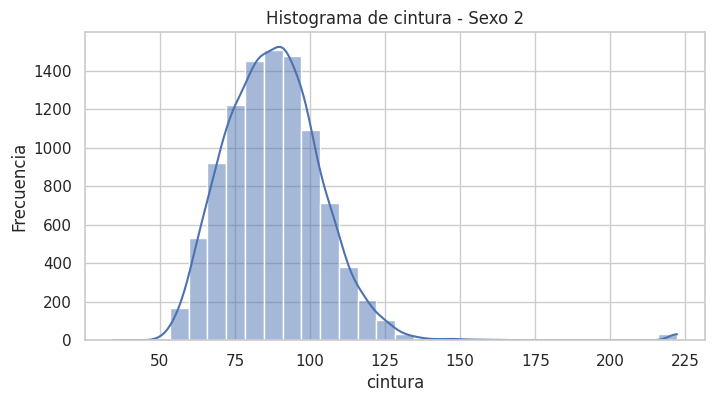

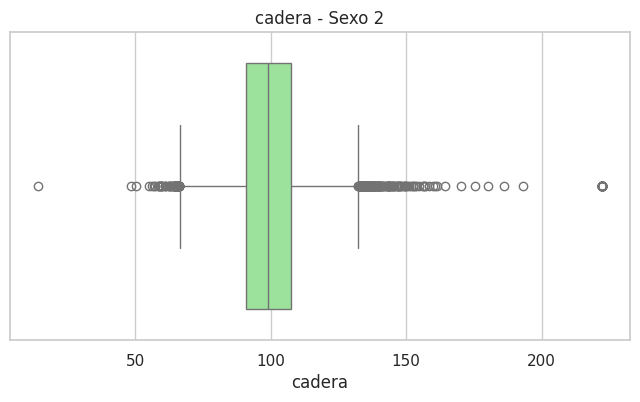

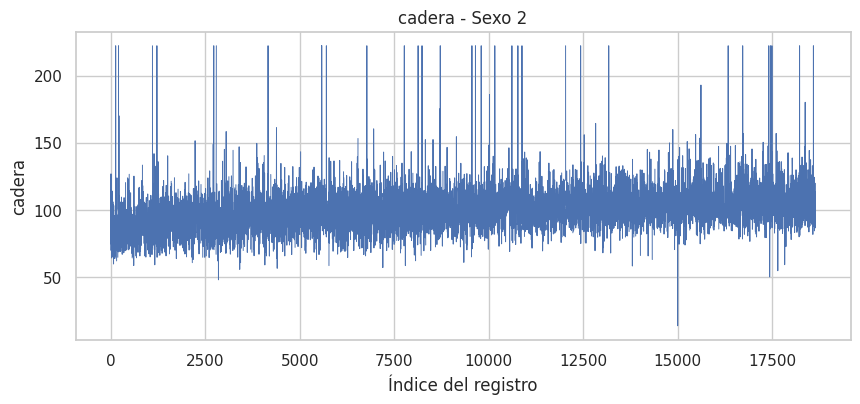

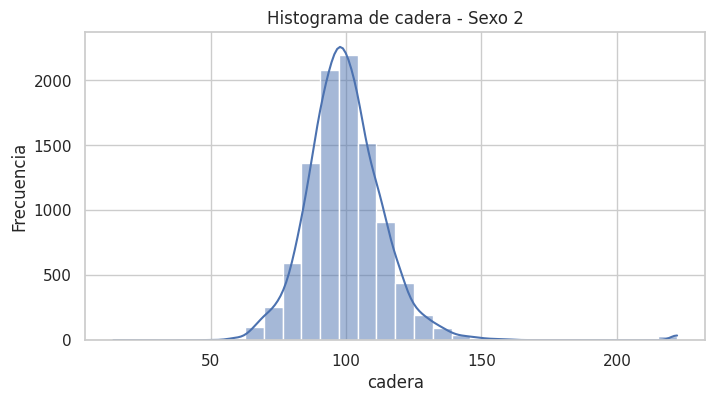

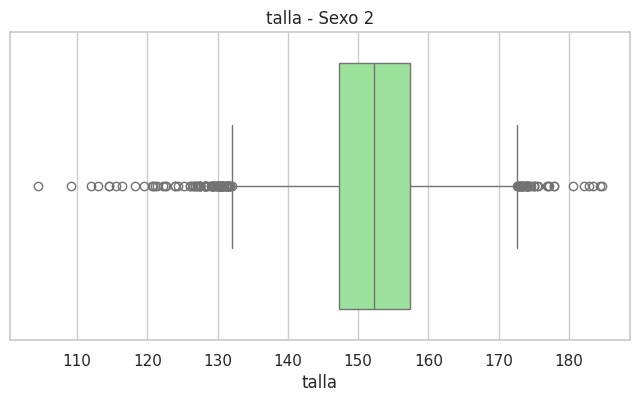

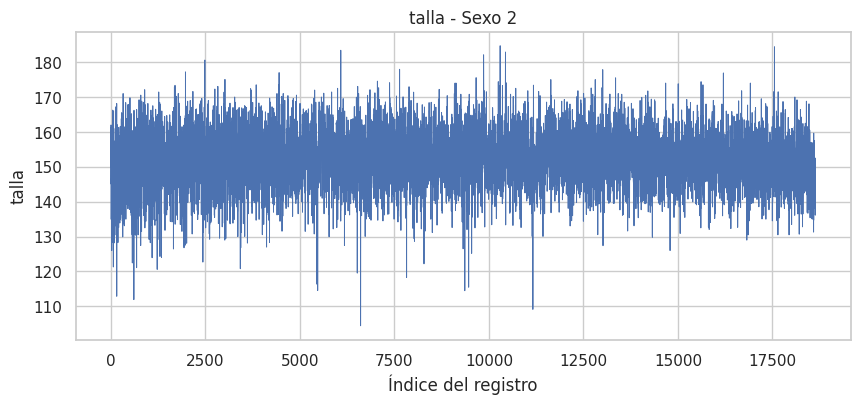

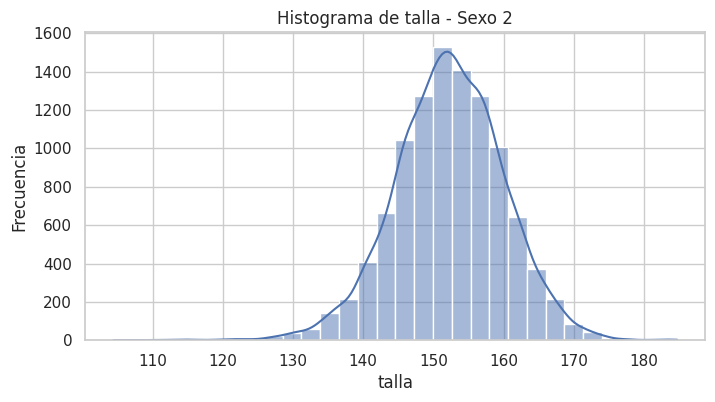

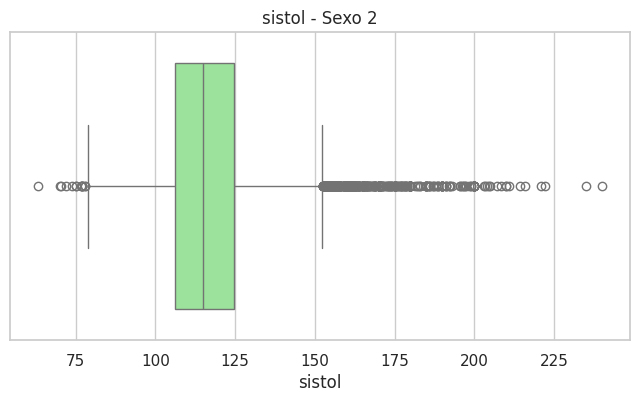

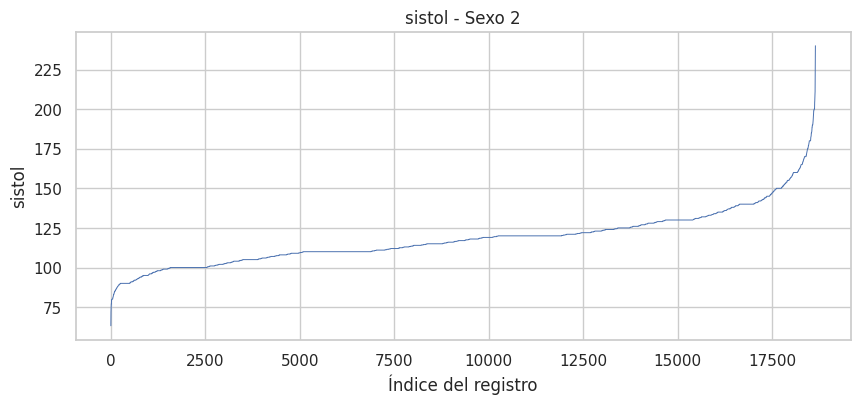

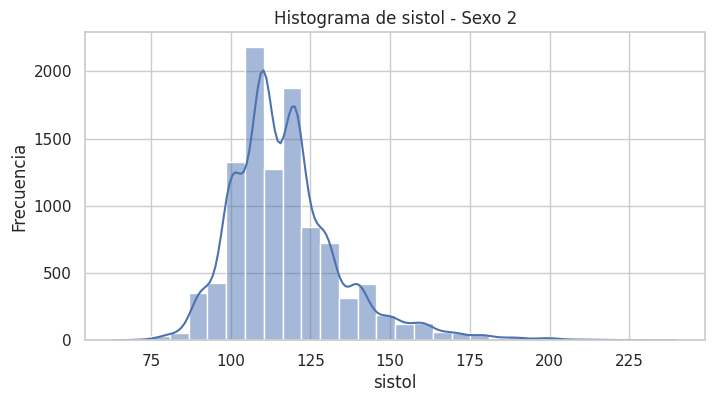

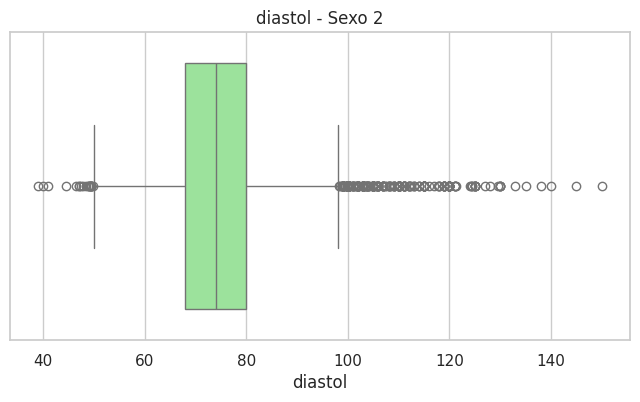

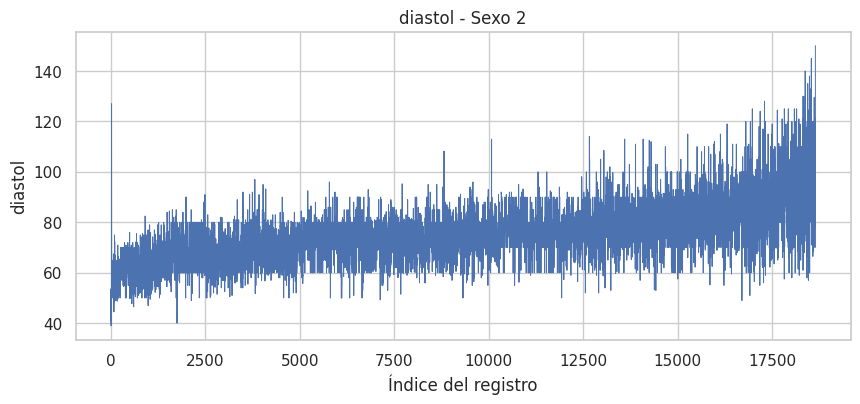

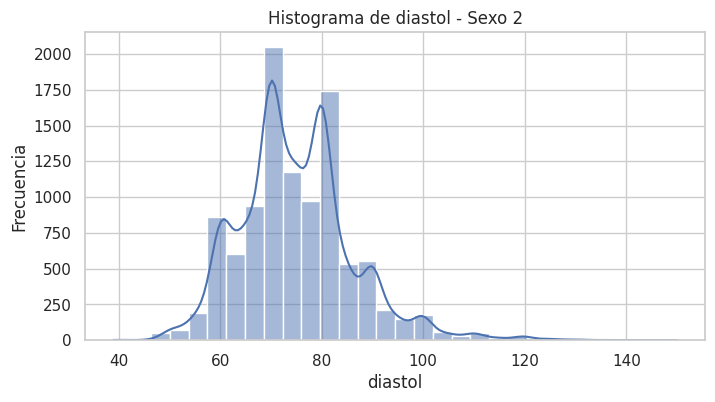

In [4]:

for sexo in sorted(df['sexo'].dropna().unique()):

    datos_sexo = df[df['sexo'] == sexo]

    print(f"\nAnálisis para sexo = {sexo}")
    print("Número de registros:", len(datos_sexo))

    for variable in variables:

        # Box plot
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=datos_sexo[variable], color='lightgreen')
        plt.title(f'{variable} - Sexo {sexo}')
        plt.xlabel(variable)
        plt.show()

        # Line plot
        plt.figure(figsize=(10, 4))
        plt.plot(
            datos_sexo.index,
            datos_sexo[variable],
            linewidth=0.7
        )
        plt.title(f'{variable} - Sexo {sexo}')
        plt.xlabel('Índice del registro')
        plt.ylabel(variable)
        plt.show()

        # Histograma
        plt.figure(figsize=(8, 4))
        sns.histplot(
            datos_sexo[variable].dropna(),
            bins=30,
            kde=True
        )
        plt.title(f'Histograma de {variable} - Sexo {sexo}')
        plt.xlabel(variable)
        plt.ylabel('Frecuencia')
        plt.show()


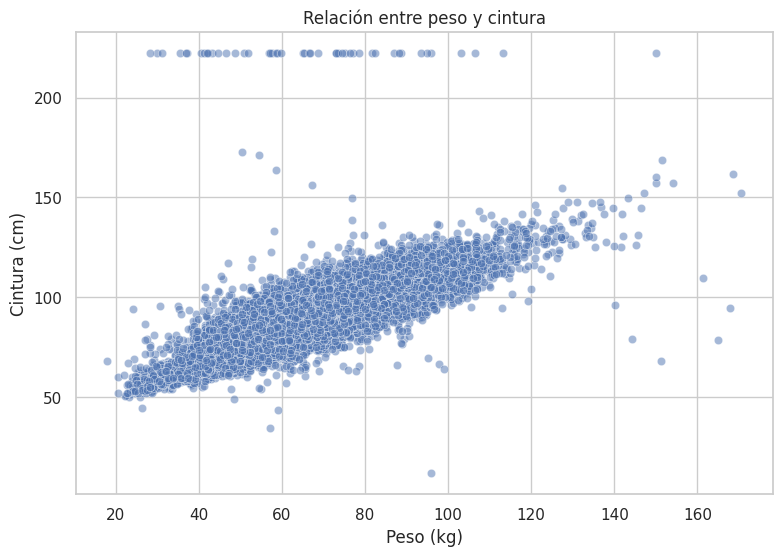

Correlación entre peso y cintura: 0.792


In [5]:

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='peso',
    y='cintura',
    alpha=0.5
)

plt.title('Relación entre peso y cintura')
plt.xlabel('Peso (kg)')
plt.ylabel('Cintura (cm)')
plt.show()

# Calcular correlación
correlacion = df['peso'].corr(df['cintura'])

print("Correlación entre peso y cintura:", round(correlacion, 3))


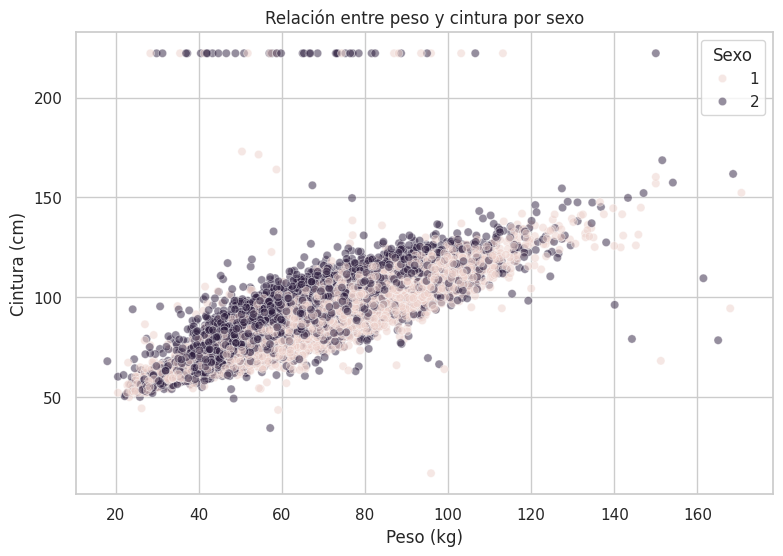

Correlación para sexo 1: 0.844
Correlación para sexo 2: 0.764


In [6]:

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='peso',
    y='cintura',
    hue='sexo',
    alpha=0.5
)

plt.title('Relación entre peso y cintura por sexo')
plt.xlabel('Peso (kg)')
plt.ylabel('Cintura (cm)')
plt.legend(title='Sexo')
plt.show()

# Correlación para cada categoría
for sexo in sorted(df['sexo'].dropna().unique()):
    datos = df[df['sexo'] == sexo]
    r = datos['peso'].corr(datos['cintura'])
    print(f'Correlación para sexo {sexo}: {r:.3f}')


In [7]:

for variable in variables:

    datos = df[variable].dropna()

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    atipicos = datos[
        (datos < limite_inferior) |
        (datos > limite_superior)
    ]

    print(f'\nVariable: {variable}')
    print('Cantidad de valores atípicos:', len(atipicos))
    print('Porcentaje:', round(len(atipicos) / len(datos) * 100, 2), '%')
    print('Límite inferior:', round(limite_inferior, 2))
    print('Límite superior:', round(limite_superior, 2))



Variable: peso
Cantidad de valores atípicos: 223
Porcentaje: 1.2 %
Límite inferior: 18.65
Límite superior: 109.45

Variable: cintura
Cantidad de valores atípicos: 131
Porcentaje: 0.73 %
Límite inferior: 43.0
Límite superior: 131.0

Variable: cadera
Cantidad de valores atípicos: 534
Porcentaje: 2.96 %
Límite inferior: 66.88
Límite superior: 127.88

Variable: talla
Cantidad de valores atípicos: 102
Porcentaje: 0.55 %
Límite inferior: 127.56
Límite superior: 185.81

Variable: sistol
Cantidad de valores atípicos: 843
Porcentaje: 4.52 %
Límite inferior: 81.25
Límite superior: 153.25

Variable: diastol
Cantidad de valores atípicos: 782
Porcentaje: 4.2 %
Límite inferior: 51.0
Límite superior: 99.0
